# 04 — Hospital Variation

The same procedure yields wildly different outcomes depending on the hospital.
Hospital efficiency (2.7d effect) is 2.1x more important than procedure choice (1.2d effect).

**Sources FINDINGS.md**: Section 1 (What Determines Faster Resolution), Section 3a (Hospital Variation)

In [1]:
import sys; sys.path.insert(0, ".")
from shared import *
import matplotlib.pyplot as plt
import seaborn as sns
import json, warnings
warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid", palette="deep", font_scale=1.1)

kidney = load_kidney()
recent = kidney[kidney["year"] >= 2022].copy()

tags = pd.read_parquet(DATA_DIR / "hospital_tags.parquet")
recent = recent.merge(tags[["CNES", "broad_type", "admission_profile", "casemix_profile", "comparability_group"]],
                      on="CNES", how="left")
recent["broad_type"] = recent["broad_type"].fillna("unknown")
print(f"Loaded {len(recent):,} recent admissions with hospital classification")
print(f"Facility types: {recent.groupby('broad_type')['CNES'].nunique().to_dict()}")

Loaded 108,697 recent admissions with hospital classification
Facility types: {'hospital_dia': 5, 'hospital_especializado': 27, 'hospital_geral': 392, 'other': 2, 'pronto_atendimento': 6, 'pronto_socorro': 10, 'unknown': 3, 'upa': 4}


## Hospital effect vs procedure effect

In [2]:
open_surg = recent[recent["PROC_REA"] == "0409010170"]
hosp_open = open_surg.groupby("CNES").agg(
    n=("DIAG_PRINC", "count"), avg_los=("DIAS_PERM", "mean"),
    avg_cost=("VAL_TOT", "mean"),
).query("n >= 20").sort_values("avg_los")

q25 = hosp_open["avg_los"].quantile(0.25)
q75 = hosp_open["avg_los"].quantile(0.75)
top_hosps = hosp_open[hosp_open["avg_los"] <= q25].index
bottom_hosps = hosp_open[hosp_open["avg_los"] >= q75].index

top_data = open_surg[open_surg["CNES"].isin(top_hosps)]
bottom_data = open_surg[open_surg["CNES"].isin(bottom_hosps)]

uretero = recent[recent["PROC_REA"] == "0409010596"]
proc_effect = open_surg["DIAS_PERM"].mean() - uretero["DIAS_PERM"].mean()
hosp_effect = bottom_data["DIAS_PERM"].mean() - top_data["DIAS_PERM"].mean()

print("=== HOSPITAL EFFECT vs PROCEDURE EFFECT ===\n")
print(f"Open Ureterolithotomy across hospitals:")
print(f"  Top-quartile: {top_data['DIAS_PERM'].mean():.2f}d (n={len(top_data):,})")
print(f"  Bottom-quartile: {bottom_data['DIAS_PERM'].mean():.2f}d (n={len(bottom_data):,})")
print(f"  Hospital effect: {hosp_effect:.2f}d\n")
print(f"Procedure comparison (all hospitals):")
print(f"  Open surgery avg: {open_surg['DIAS_PERM'].mean():.2f}d")
print(f"  Ureteroscopy avg: {uretero['DIAS_PERM'].mean():.2f}d")
print(f"  Procedure effect: {proc_effect:.2f}d\n")
print(f">>> Hospital effect ({hosp_effect:.1f}d) is {hosp_effect/proc_effect:.1f}x LARGER "
      f"than procedure effect ({proc_effect:.1f}d)")

=== HOSPITAL EFFECT vs PROCEDURE EFFECT ===

Open Ureterolithotomy across hospitals:
  Top-quartile: 1.78d (n=4,649)
  Bottom-quartile: 4.45d (n=4,659)
  Hospital effect: 2.66d

Procedure comparison (all hospitals):
  Open surgery avg: 3.09d
  Ureteroscopy avg: 1.85d
  Procedure effect: 1.24d

>>> Hospital effect (2.7d) is 2.1x LARGER than procedure effect (1.2d)


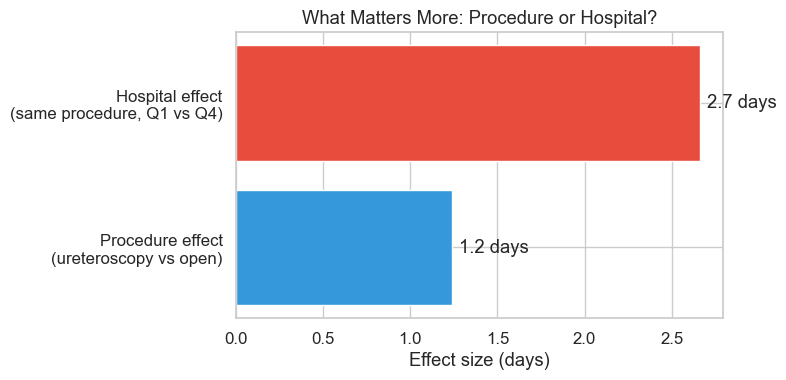

In [3]:
fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(["Procedure effect\n(ureteroscopy vs open)", "Hospital effect\n(same procedure, Q1 vs Q4)"],
               [proc_effect, hosp_effect], color=["#3498db", "#e74c3c"])
ax.bar_label(bars, fmt="%.1f days", padding=5)
ax.set_xlabel("Effect size (days)")
ax.set_title("What Matters More: Procedure or Hospital?")
plt.tight_layout()
plt.savefig(PLOT_DIR / "04_effect_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

## Worst hospitals per procedure (2022+)

In [4]:
cnes_type_map = tags.set_index("CNES")["broad_type"].to_dict()

for proc_code, proc_name, sys_median in [
    ("0409010596", "Ureteroscopy", None),
    ("0409010170", "Open Ureterolithotomy", None),
    ("0415010012", "Clinical Management", None),
]:
    proc_data = recent[recent["PROC_REA"] == proc_code]
    hosp = proc_data.groupby("CNES").agg(
        n=("DIAG_PRINC", "count"), avg_los=("DIAS_PERM", "mean"),
        total_bd=("DIAS_PERM", "sum"), avg_cost=("VAL_TOT", "mean"),
        city=("MUNIC_MOV", "first"), mortality=("MORTE", "mean"),
    ).query("n >= 20").sort_values("avg_los", ascending=False)

    hosp["facility_type"] = hosp.index.map(cnes_type_map).fillna("unknown")
    median_los = hosp["avg_los"].median()
    hosp["excess_bd"] = ((hosp["avg_los"] - median_los) * hosp["n"]).clip(lower=0)

    print(f"\n--- {proc_name} (median LOS: {median_los:.1f}d, {len(hosp)} hospitals) ---")
    print(f"  By facility type: {hosp['facility_type'].value_counts().to_dict()}")
    worst = hosp.sort_values("excess_bd", ascending=False).head(5)
    for cnes, r in worst.iterrows():
        print(f"  CNES {cnes} ({city_name(r['city'])}, {r['facility_type']}): "
              f"n={r['n']:.0f}, LOS {r['avg_los']:.1f}d "
              f"(+{r['avg_los']-median_los:.1f}d), excess bed-days: {r['excess_bd']:.0f}, "
              f"mortality: {r['mortality']*100:.1f}%")


--- Ureteroscopy (median LOS: 1.5d, 99 hospitals) ---
  By facility type: {'hospital_geral': 93, 'hospital_especializado': 3, 'hospital_dia': 3}
  CNES 2755130 (Pres. Prudente, hospital_geral): n=2842, LOS 2.7d (+1.2d), excess bed-days: 3446, mortality: 0.2%
  CNES 9465464 (São Paulo, hospital_geral): n=1390, LOS 3.0d (+1.5d), excess bed-days: 2046, mortality: 0.2%
  CNES 2081695 (Sorocaba, hospital_geral): n=1137, LOS 3.0d (+1.5d), excess bed-days: 1699, mortality: 0.5%
  CNES 2688689 (São Paulo, hospital_geral): n=354, LOS 5.3d (+3.8d), excess bed-days: 1359, mortality: 0.0%
  CNES 6095666 (Bauru, hospital_geral): n=1164, LOS 2.6d (+1.1d), excess bed-days: 1224, mortality: 0.0%

--- Open Ureterolithotomy (median LOS: 2.9d, 105 hospitals) ---
  By facility type: {'hospital_geral': 101, 'hospital_dia': 2, 'hospital_especializado': 1, 'other': 1}
  CNES 2081695 (Sorocaba, hospital_geral): n=996, LOS 4.3d (+1.4d), excess bed-days: 1406, mortality: 1.3%
  CNES 2688689 (São Paulo, hospita


--- Clinical Management (median LOS: 2.0d, 67 hospitals) ---
  By facility type: {'hospital_geral': 67}
  CNES 2688689 (São Paulo, hospital_geral): n=237, LOS 4.5d (+2.4d), excess bed-days: 577, mortality: 0.4%
  CNES 2078015 (São Paulo, hospital_geral): n=922, LOS 2.6d (+0.6d), excess bed-days: 556, mortality: 0.2%
  CNES 2077477 (São Paulo, hospital_geral): n=259, LOS 4.1d (+2.0d), excess bed-days: 524, mortality: 1.2%
  CNES 0008028 (353440, hospital_geral): n=134, LOS 4.2d (+2.1d), excess bed-days: 285, mortality: 0.7%
  CNES 2082829 (São Paulo, hospital_geral): n=76, LOS 5.5d (+3.5d), excess bed-days: 267, mortality: 1.3%


## Ureteroscopy LOS distribution across hospitals

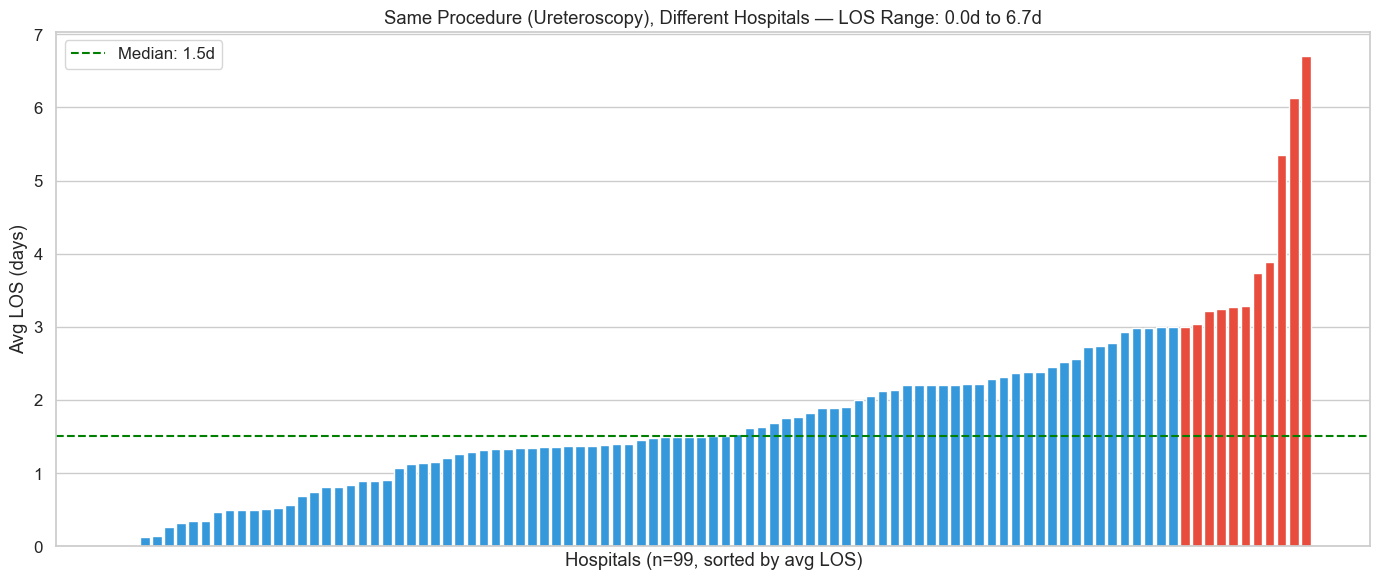

In [5]:
hosp_uretero = uretero.groupby("CNES").agg(
    n=("DIAG_PRINC", "count"), avg_los=("DIAS_PERM", "mean"),
    city=("MUNIC_MOV", "first"),
).query("n >= 20").sort_values("avg_los")

fig, ax = plt.subplots(figsize=(14, 6))
colors = ["#e74c3c" if los > 3 else "#3498db" for los in hosp_uretero["avg_los"]]
ax.bar(range(len(hosp_uretero)), hosp_uretero["avg_los"], color=colors, width=0.8)
ax.axhline(hosp_uretero["avg_los"].median(), color="green", linestyle="--", label=f"Median: {hosp_uretero['avg_los'].median():.1f}d")
ax.set_xlabel(f"Hospitals (n={len(hosp_uretero)}, sorted by avg LOS)")
ax.set_ylabel("Avg LOS (days)")
ax.set_title("Same Procedure (Ureteroscopy), Different Hospitals — LOS Range: "
             f"{hosp_uretero['avg_los'].min():.1f}d to {hosp_uretero['avg_los'].max():.1f}d")
ax.legend()
ax.set_xticks([])
plt.tight_layout()
plt.savefig(PLOT_DIR / "04_ureteroscopy_hospital_variation.png", dpi=150, bbox_inches="tight")
plt.show()

## Top Performer Deep Dive (data-driven)

Instead of hardcoding a specific hospital, we identify the top 3 overperformers among
Hospital Geral facilities with at least 20 cases. These are hospitals that achieve
the lowest LOS for the same procedures.

In [6]:
geral_recent = recent[recent["broad_type"] == "hospital_geral"]
hosp_stats = geral_recent.groupby("CNES").agg(
    n=("DIAG_PRINC", "count"),
    avg_los=("DIAS_PERM", "mean"),
    pct_uretero=("has_new_proc", "mean"),
    pct_definitive=("proc_category", lambda x: x.isin(["SURGICAL", "INTERVENTIONAL"]).mean()),
    city=("city_name", "first"),
    admission_profile=("admission_profile", "first"),
).query("n >= 20").sort_values("avg_los")

sys_avg_los = recent["DIAS_PERM"].mean()
sys_def_rate = recent["proc_category"].isin(["SURGICAL", "INTERVENTIONAL"]).mean()

for rank_i, (cnes, r) in enumerate(hosp_stats.head(3).iterrows(), 1):
    print(f"=== TOP PERFORMER #{rank_i}: CNES {cnes} ({r['city']}) ===")
    print(f"  Admission profile: {r['admission_profile']}")
    print(f"  Total patients (2022+): {r['n']:,.0f}")
    print(f"  Avg LOS: {r['avg_los']:.2f}d (system avg: {sys_avg_los:.2f}d)")
    print(f"  Ureteroscopy rate: {r['pct_uretero']*100:.1f}%")
    print(f"  Definitive treatment rate: {r['pct_definitive']*100:.1f}%")
    print(f"    (system avg: {sys_def_rate*100:.1f}%)")

    cnes_open = hosp_open[hosp_open.index == cnes]
    if len(cnes_open) > 0:
        rank_val = (hosp_open["avg_los"] <= cnes_open.iloc[0]["avg_los"]).sum()
        print(f"  Open ureterolithotomy rank: #{rank_val} of {len(hosp_open)}")
        print(f"    LOS: {cnes_open.iloc[0]['avg_los']:.1f}d")
    print()

=== TOP PERFORMER #1: CNES 2082853 (350590) ===
  Admission profile: mixed
  Total patients (2022+): 135
  Avg LOS: 0.23d (system avg: 2.26d)
  Ureteroscopy rate: 2.2%
  Definitive treatment rate: 55.6%
    (system avg: 58.3%)

=== TOP PERFORMER #2: CNES 2078414 (351740) ===
  Admission profile: mixed
  Total patients (2022+): 116
  Avg LOS: 0.30d (system avg: 2.26d)
  Ureteroscopy rate: 26.7%
  Definitive treatment rate: 31.0%
    (system avg: 58.3%)

=== TOP PERFORMER #3: CNES 9680500 (351670) ===
  Admission profile: elective_dominant
  Total patients (2022+): 154
  Avg LOS: 0.45d (system avg: 2.26d)
  Ureteroscopy rate: 66.9%
  Definitive treatment rate: 77.3%
    (system avg: 58.3%)



## Santos case study

In [7]:
santos = recent[recent["MUNIC_MOV"] == "354870"]
santos_types = santos.groupby("broad_type")["CNES"].nunique().to_dict()
print("=== SANTOS ===\n")
print(f"Facility types in Santos: {santos_types}")
print(f"Total patients (2022+): {len(santos):,}")
print(f"Avg LOS: {santos['DIAS_PERM'].mean():.2f}d")
print(f"Ureteroscopy rate: {santos['has_new_proc'].mean()*100:.1f}%")
print(f"Mortality: {santos['MORTE'].mean()*100:.2f}%")

print("\nSame procedure, Santos vs system:")
for proc, name in [("0409010170", "Open Ureterolithotomy"), ("0415010012", "Clinical Mgmt")]:
    s = santos[santos["PROC_REA"] == proc]
    sys_all = recent[recent["PROC_REA"] == proc]
    if len(s) > 10:
        diff = s["DIAS_PERM"].mean() - sys_all["DIAS_PERM"].mean()
        print(f"  {name}: Santos {s['DIAS_PERM'].mean():.1f}d vs system {sys_all['DIAS_PERM'].mean():.1f}d "
              f"({abs(diff):.1f}d {'faster' if diff < 0 else 'slower'})")

=== SANTOS ===

Facility types in Santos: {'hospital_geral': 4}
Total patients (2022+): 1,663
Avg LOS: 1.45d
Ureteroscopy rate: 2.2%
Mortality: 0.30%

Same procedure, Santos vs system:
  Open Ureterolithotomy: Santos 1.9d vs system 3.1d (1.2d faster)
  Clinical Mgmt: Santos 1.3d vs system 2.1d (0.8d faster)


## Save metrics

In [8]:
top_performer = hosp_stats.head(1)
metrics = {
    "hospital_effect_days": round(hosp_effect, 2),
    "procedure_effect_days": round(proc_effect, 2),
    "ratio": round(hosp_effect / proc_effect, 1),
    "top_quartile_los": round(top_data["DIAS_PERM"].mean(), 2),
    "bottom_quartile_los": round(bottom_data["DIAS_PERM"].mean(), 2),
    "ureteroscopy_hospital_range": [round(hosp_uretero["avg_los"].min(), 1),
                                     round(hosp_uretero["avg_los"].max(), 1)],
    "n_hospitals_ureteroscopy": len(hosp_uretero),
    "top_performer_cnes": top_performer.index[0] if len(top_performer) > 0 else None,
    "top_performer_avg_los": round(float(top_performer.iloc[0]["avg_los"]), 2) if len(top_performer) > 0 else None,
}
with open(METRICS_DIR / "hospital_variation.json", "w") as f:
    json.dump(metrics, f, indent=2)
print("Saved hospital_variation.json")

Saved hospital_variation.json
